In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
### Commentaires
from itertools import combinations
###
from sklearn.preprocessing import StandardScaler
###
###############  Random Forest model and SHAP for Cost prediction
##### Random Forest modele
from sklearn.model_selection import cross_validate, cross_val_score
#from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer,mean_squared_error, r2_score
#from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
####
import shap
###
from sklearn.feature_selection import VarianceThreshold
###
start = time.time()
input_space = pd.read_excel('Input_Space.xlsx',engine='openpyxl')
output_space = pd.read_excel('Output_Space.xlsx',engine='openpyxl')
########  Filtrer les données avec la Variance   
vt = VarianceThreshold() # Threshold default is 0
_ = vt.fit(input_space)
var_vector_mask = vt.get_support()
    #var_vector_mask 
input_space = input_space.loc[:, var_vector_mask]
col_names=input_space.columns
print("La durée d execution en seconde:",time.time() - start)

La durée d execution en seconde: 0.5205426216125488


In [2]:
#####  Creation des fakes variables 
start = time.time()
Vars=input_space.columns
input_space[[v + "_fake" for v in Vars]]=input_space.iloc[np.random.permutation(input_space.index)].reset_index(drop=True)
print("La durée d execution en seconde:",time.time() - start)

La durée d execution en seconde: 0.015388250350952148


In [3]:
###### Application de la standardisation avec “StandardScaler” dans le package #preprocessing.
start = time.time()
ss = StandardScaler()
output_space = pd.DataFrame(ss.fit_transform(output_space),columns =output_space.columns)
input_space = pd.DataFrame(ss.fit_transform(input_space),columns=input_space.columns)
#print(output_space )
print("La durée d execution en seconde:",time.time() - start)


La durée d execution en seconde: 0.02100396156311035


In [4]:
###### Fonction permettant de comparer les variables avec leur fakes
def ft_from_fake(ft_input):
    ft=ft_input
    for i in Vars:
        for col in output_space.columns:
            if ft.loc[i,col] <= ft.loc[i+ "_fake",col]:
                ft.loc[i,col]=0
                #ft[ft < 0.005] = 0
    ft.drop(ft.tail(len(Vars)).index,inplace = True)
    return ft

In [5]:
#import asyncio
start = time.time()
feature_importance=pd.DataFrame(np.nan, index=input_space.columns, columns=output_space.columns)
Output= output_space.to_dict('series')
X = input_space
for  col in list(output_space.columns.values):
    model = RandomForestRegressor(n_estimators =100,random_state =0)
    #model = RandomForestRegressor(n_estimators =900,max_depth =70,random_state =101)
    #Score_col=cross_val_score(model, X ,Output[col], cv=10, scoring=make_scorer(mean_squared_error))
    model_col=model.fit(X, Output[col]) 
    # Make prediction
    #predictions = model.predict(X)
    #print(predictions)
    # R-squared scores
    #r2 = r2_score(Output[col], predictions)
    #print(r2)
    ##### SHAP explaination
    shap_values_col= shap.TreeExplainer(model_col).shap_values(X)
    #vals_col= np.abs(shap_values_col).mean(0)
    feature_importance[col]=np.abs(shap_values_col).mean(0)
    
print("La durée d execution en seconde:",time.time() - start) 


La durée d execution en seconde: 3.809666395187378


In [6]:
########################### SHAP VALUES IMPORTANCE DATAFRAME
feature_importance=1.15*ft_from_fake(feature_importance)
feature_importance[feature_importance > 1] = 1
#print("La durée d execution en seconde:",time.time() - start)

# Summary plot  xlim=[0,1]

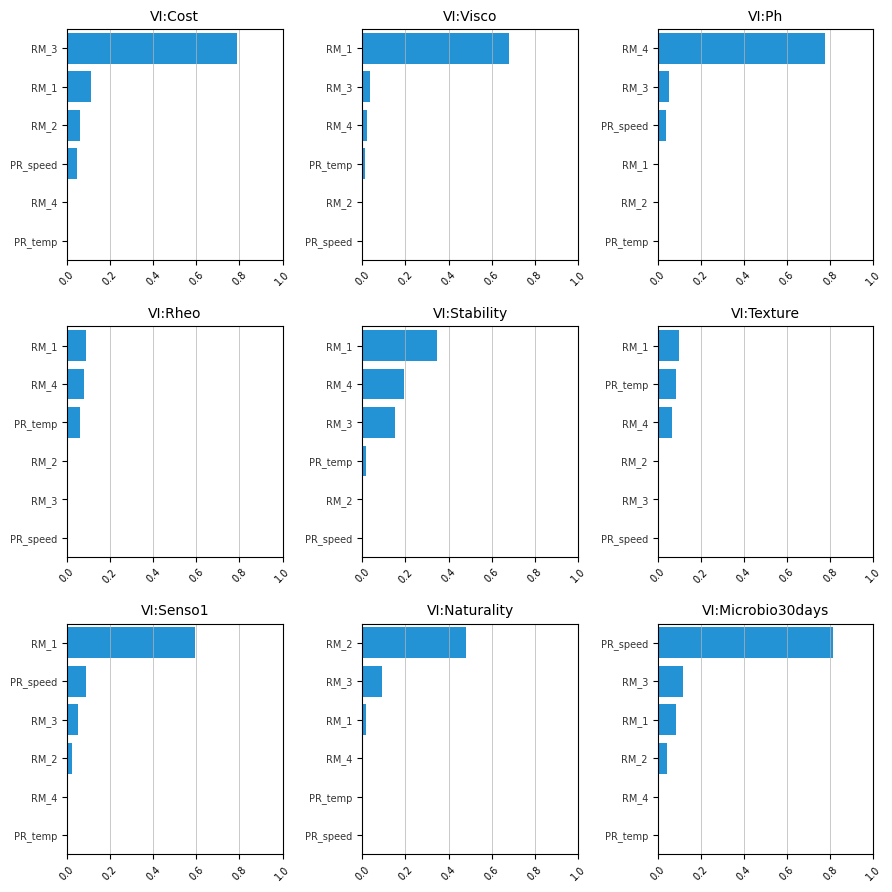

In [7]:
import seaborn as sns
from math import ceil
#### Visualisation et sauvegarde du pareto graph    color='#1874CD' 
taille=ceil(len(output_space.columns)/3)
fig = plt.figure(figsize = (3*taille,3*taille))
for i, col in enumerate(feature_importance.columns):
    ax = fig.add_subplot(taille, 3, i+1)
    #feature_importance[col].plot(kind='barh')
    sns.barplot(x=feature_importance[col], y=feature_importance.index, order=feature_importance[col].sort_values(ascending = False).index,color='#069AF3')
    plt.xticks(np.linspace(0,1,6,endpoint=True),fontsize=7,rotation=45)
    plt.yticks(fontsize=7,color ='0.2')
    plt.xlim([0,1])
    ax.set(xlabel=None)
    plt.title("VI:"+ col,fontsize=10)
    plt.grid(axis='x',color='0.7',linewidth=0.5)
plt.tight_layout(pad=1,h_pad=1.4)   
#plt.show()
plt.savefig('latex/pareto_path')

# Second ShAP values

In [8]:
######  de supprimer  les variables fakes
#X= pd.DataFrame(X)
for col in X.columns:
    if  '_fake' in col:
        del X[col]
#X  

In [9]:
start = time.time()
feature_importance_clean=pd.DataFrame(np.nan, index=input_space.columns, columns=output_space.columns)
i=feature_importance.index
d = {}
Index={}
list_of_datasets=list()
#Output_clean= output_space.to_dict('series')
feature_importance_clean=pd.DataFrame(np.nan, index=input_space.columns, columns=output_space.columns)
for  col in list(feature_importance.columns.values):
    index =feature_importance[col]==0
    result = i[index]
    Index[col]=result.tolist()
    #print(Index['Cost'])
    d[col]=pd.DataFrame(X.drop(Index[col], axis=1))
    model_col=model.fit(d[col], Output[col])
    shap_values_col= shap.TreeExplainer(model_col).shap_values(d[col])
    vals_col=pd.Series(np.abs(shap_values_col).mean(0),index=d[col].columns)
    feature_importance_clean[col]=pd.DataFrame(pd.concat([vals_col[lambda x: x != ''].rename(col)], axis=1))  
print("La durée d execution en seconde:",time.time() - start)    
#feature_importance_clean   

La durée d execution en seconde: 4.105021715164185


In [10]:
########################### SHAP VALUES IMPORTANCE DATAFRAME
feature_importance_clean=1.15*feature_importance_clean
feature_importance_clean[feature_importance_clean > 1] = 1
feature_importance_clean

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
RM_1,0.222118,0.786841,NaN,0.261245,0.479683,0.184105,0.730301,0.069053,0.126029
RM_2,0.074970,NaN,NaN,NaN,NaN,NaN,0.049056,0.870966,0.047035
RM_3,0.878181,0.075959,0.058575,NaN,0.244269,NaN,0.094857,0.165232,0.152375
RM_4,NaN,0.061337,0.894398,0.358785,0.289590,0.341263,NaN,NaN,NaN
PR_temp,NaN,0.025340,NaN,0.080160,0.050153,0.138482,NaN,NaN,NaN
PR_speed,0.035557,NaN,0.045446,NaN,NaN,NaN,0.085011,NaN,0.845386


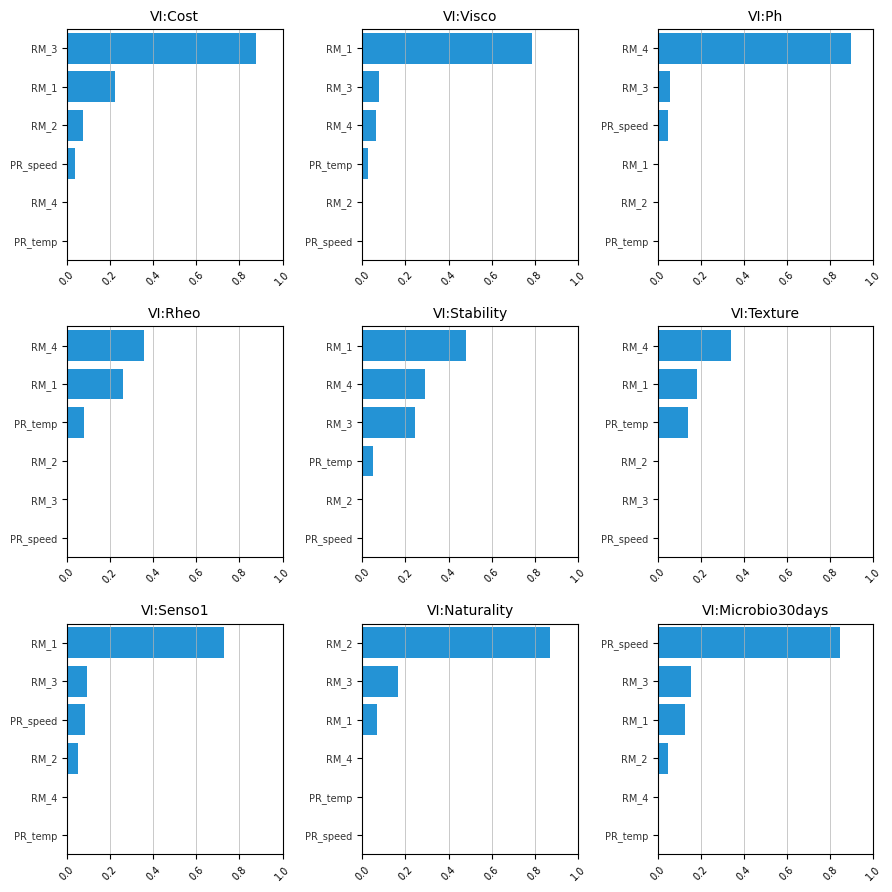

In [11]:
import seaborn as sns
from math import ceil
#### Visualisation et sauvegarde du pareto graph
taille=ceil(len(output_space.columns)/3)
fig = plt.figure(figsize = (3*taille,3*taille))
for i, col in enumerate(feature_importance_clean.columns):
    ax = fig.add_subplot(taille, 3, i+1)
    #feature_importance[col].plot(kind='barh')
    sns.barplot(x=feature_importance_clean[col], y=feature_importance_clean.index,order=feature_importance_clean[col].sort_values(ascending = False).index,color='#069AF3')
    plt.xticks(np.linspace(0,1,6,endpoint=True),fontsize=7,rotation=45)
    plt.yticks(fontsize=7,color ='0.2')
    plt.xlim([0,1])
    ax.set(xlabel=None)
    plt.title("VI:"+ col,fontsize=10)
    plt.grid(axis='x',color='0.7',linewidth=0.5)
plt.tight_layout(pad=1,h_pad=1.4)   
#plt.show()
plt.savefig('latex/pareto_clean')

# heatmap plot 

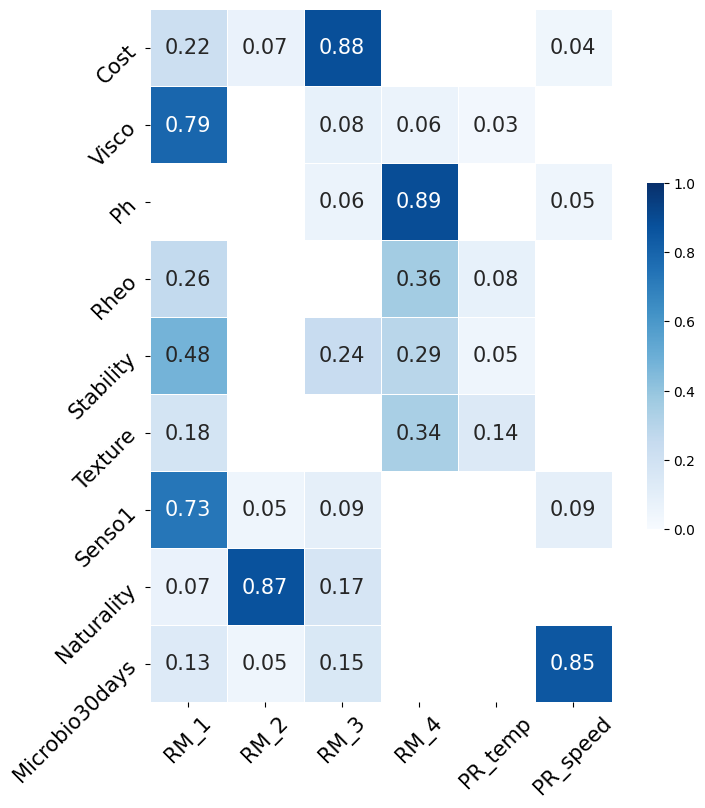

In [12]:
#### Visualisation et sauvegarde du matrix des shap values
# Generate a mask for the upper triangle
#mask = np.triu(np.ones_like(feature_importance, dtype=bool))
f, ax = plt.subplots(figsize=(taille*3,taille*3 ))
heatmap = sns.heatmap(feature_importance_clean.T.round(2),
                      #mask = mask,
                      square = True,
                      linewidths = .5,
                      cmap ='Blues',
                      cbar_kws = {'shrink': .5,
                               'ticks' : [0.0, 0.2, 0.4, 0.6, 0.8, 1]},
                      vmin = 0,
                      vmax = 1,
                      annot = True,
                      annot_kws = {"size": 15})
 #add the column names as labels              
plt.xticks(fontsize=15,rotation=45)
plt.yticks(fontsize=15,rotation=45)
#plt.show()
plt.savefig('latex/matrix_clean')